# Plotter hTPC

In [1]:
from pathlib import Path
import sys
PROJECT_ROOT = Path.cwd().parents[0]
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

In [2]:
FIG_SINGLE = (3.34, 2.5)
FIG_DOUBLE = (6.69, 3.5)

plt.rcParams.update({
    # Figure
    "figure.figsize": FIG_SINGLE,
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
    
    # Colours
    'image.cmap': 'inferno',

    # Fonts
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 7,

    # --------------------------
    # Axes labels and titles
    # --------------------------
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "axes.labelpad": 6,
    "axes.titlepad": 8,

    # --------------------------
    # Axes appearance
    # --------------------------
    "axes.linewidth": 1.2,
    "axes.edgecolor": "black",
    "axes.labelcolor": "black",

    # --------------------------
    # Ticks
    # --------------------------
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.major.size": 16,
    "ytick.major.size": 16,
    "xtick.minor.size": 8,
    "ytick.minor.size": 8,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.minor.width": 0.8,
    "ytick.minor.width": 0.8,
    "xtick.major.pad": 2,
    "ytick.major.pad": 2,
    "xtick.color": "black",
    "ytick.color": "black",

    # Lines
    "lines.linewidth": 1.0,
    "lines.markersize": 3,


    # Legend
    "legend.fontsize": 6,
    "legend.frameon": False,
    "legend.handlelength": 1.2,
    "legend.handletextpad": 0.4,
    "legend.borderaxespad": 0.4,

    # Grid
    "axes.grid": False,
    "grid.color": "0.85",
    "grid.linewidth": 0.4,
    "grid.alpha": 0.8,

    # Export fonts as editable text in vector files
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

## LCE map

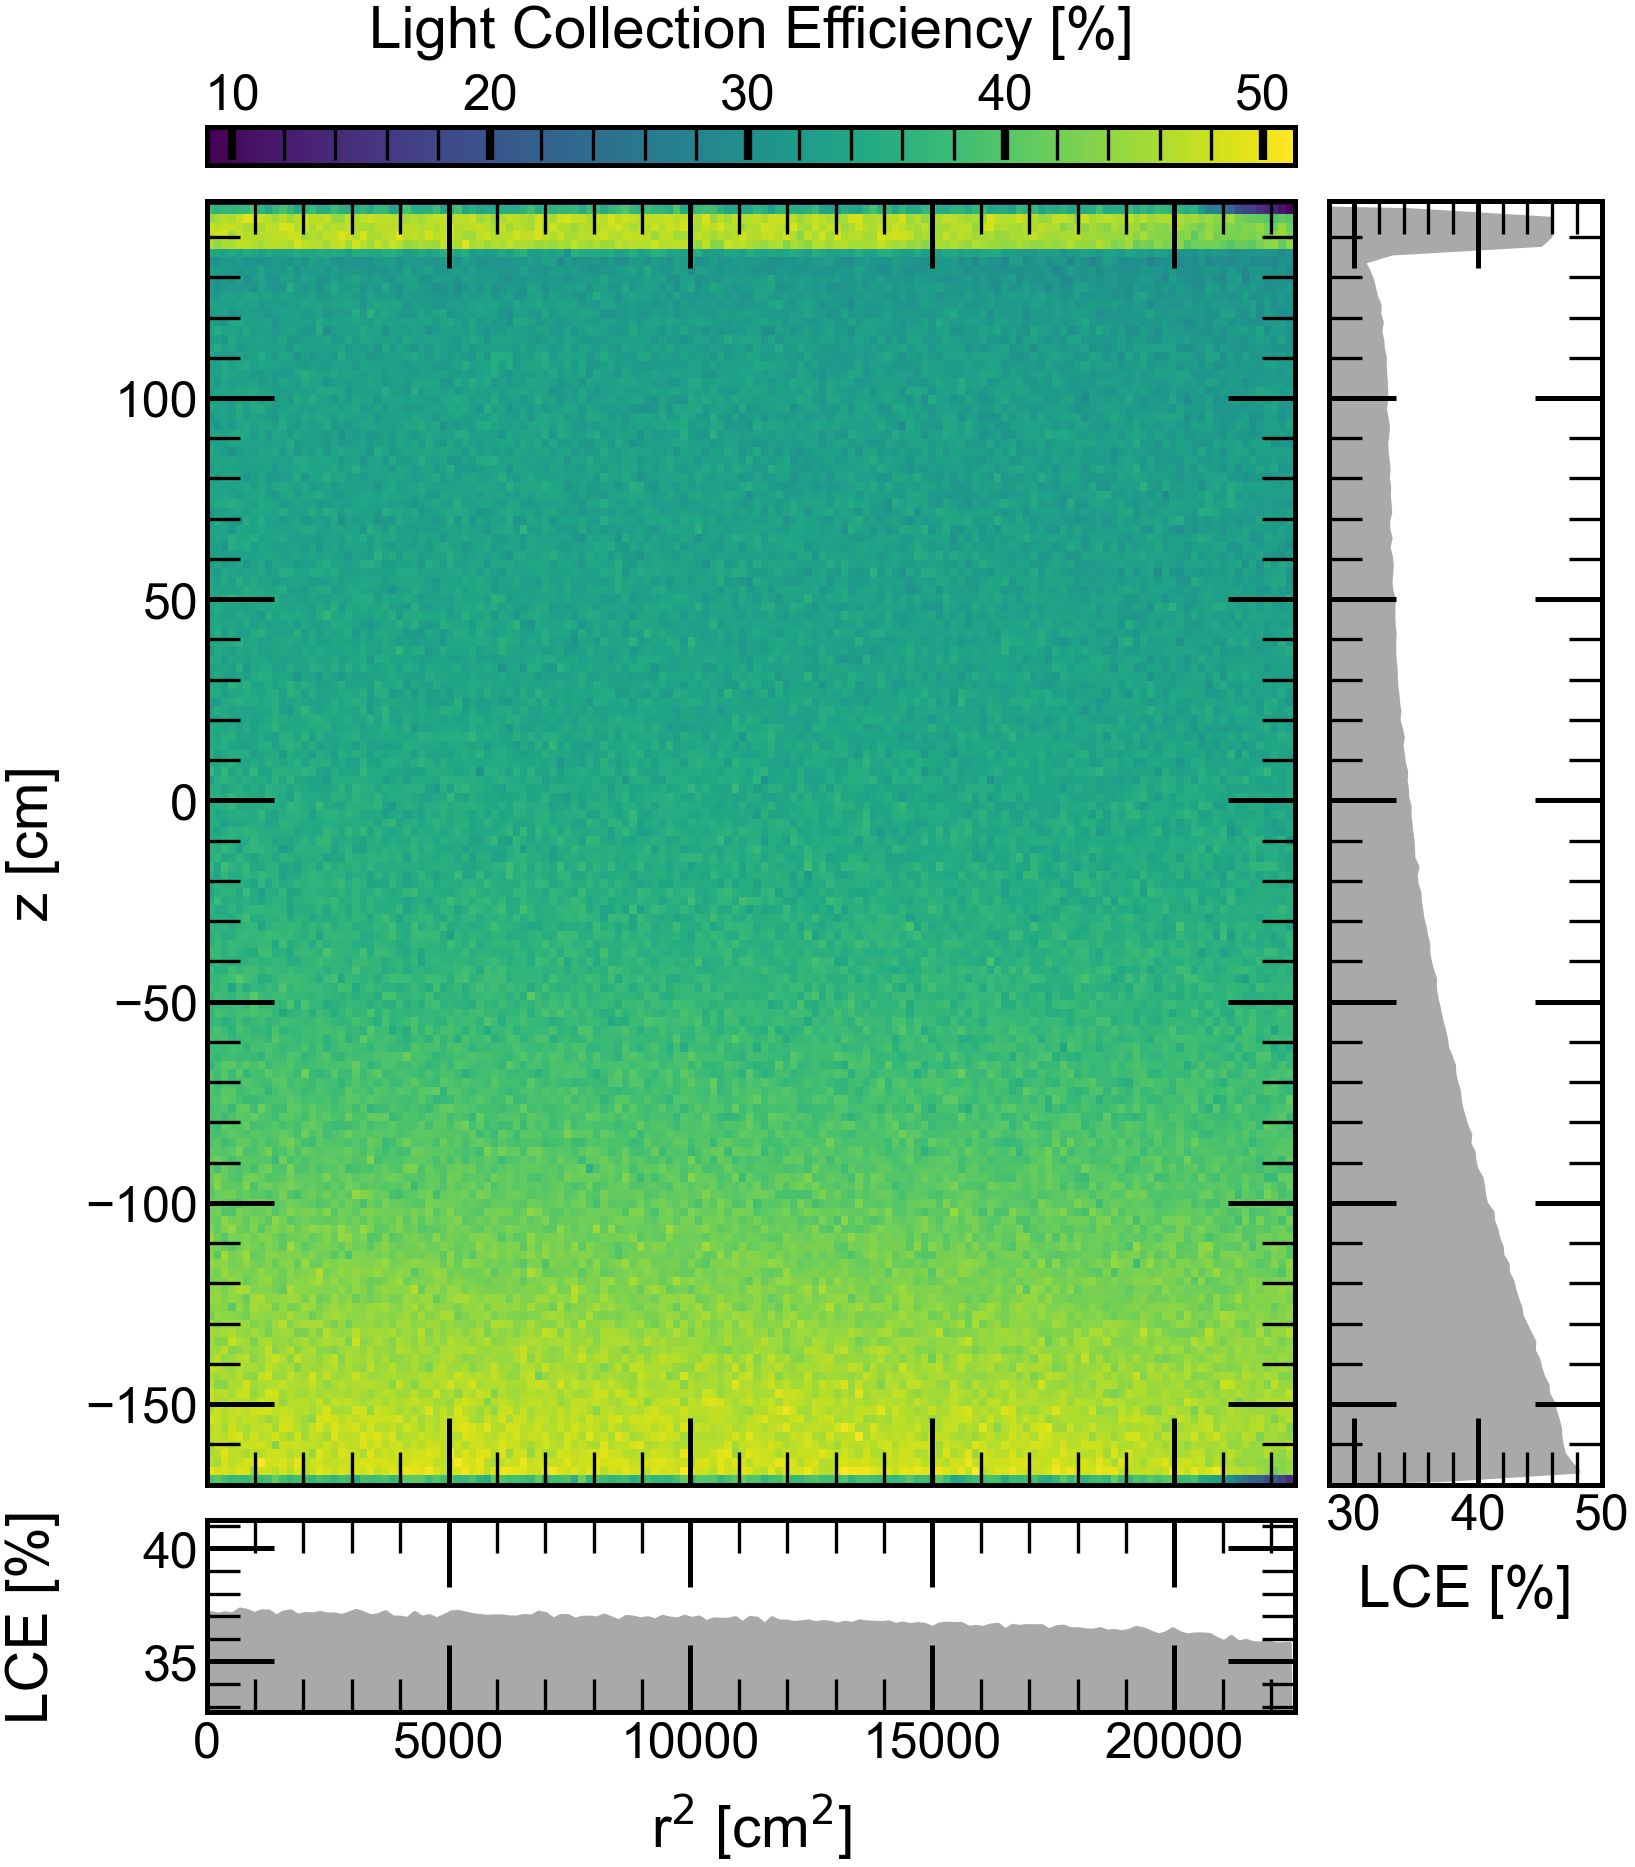

In [47]:
import h5py
from scipy.interpolate import interp1d
from scipy.signal import savgol_filter

# Load maps and compute 1D projections
hdfSaph = h5py.File("data/g1mapSapphire.hdf5", "r")
LCEbinsrad = hdfSaph["bins"]["0"][:]
LCEbinsz = hdfSaph["bins"]["1"][:]
LCEmap = hdfSaph["templates"]["g1mapSapphire"][:]/0.4*100

hdfSaph30 = h5py.File("data/g1mapSapphire30.hdf5", "r")
LCEmapSaph30 = hdfSaph30["templates"]["g1mapSapphire30"][:]/0.4*100

hdfLXe = h5py.File("data/g1mapLXe.hdf5", "r")
LCEmapLXe = hdfLXe["templates"]["g1mapLXe"][:]/0.4*100

hdfPTFE = h5py.File("data/g1mapPTFE.hdf5", "r")
LCEmapPTFE = hdfPTFE["templates"]["g1mapPTFE"][:]/0.4*100

LCEbinsradcenter = (LCEbinsrad[:-1] + LCEbinsrad[1:]) / 2
LCEbinszcenter = (LCEbinsz[:-1] + LCEbinsz[1:]) / 2

# 2D map with projections only
fig = plt.figure(figsize=(6, 7))
gs = fig.add_gridspec(3, 2, width_ratios=[4, 1], height_ratios=[0.12, 4, 0.6], wspace=0.05, hspace=0.07)

ax_map = fig.add_subplot(gs[1, 0])
ax_cb = fig.add_subplot(gs[0, 0])
ax_proj = fig.add_subplot(gs[1, 1])
ax_rad = fig.add_subplot(gs[2, 0], sharex=ax_map)

cmap = mpl.cm.viridis.copy()
mesh = ax_map.pcolormesh(LCEbinsrad/100, LCEbinsz/10, LCEmap.T, cmap=cmap, vmin=9)
cbar = fig.colorbar(mesh, cax=ax_cb, orientation='horizontal')
ax_cb.xaxis.set_label_position('top')
ax_cb.xaxis.set_ticks_position('top')
ax_cb.tick_params(axis="x", which="major", length=8, width=2.0)
cbar.set_label('Light Collection Efficiency [%]')

ax_map.set_ylabel("z [cm]")
ax_map.xaxis.set_tick_params(labelleft=False)
ax_map.set_ylim(-170, 149)
ax_map.set_xlim(0, 22500)

# vertical projection (z-averaged) on the right
LCEmap_zproj = LCEmap.mean(axis=0)
ax_proj.plot(LCEmap_zproj, LCEbinszcenter/10, linewidth=0, color='darkgray', alpha=1)
ax_proj.fill_betweenx(LCEbinszcenter/10, LCEmap_zproj, x2=0, color='darkgray', alpha=1)
ax_proj.set_xlabel("LCE [%]")
ax_proj.set_xlim(28, 50)
ax_proj.yaxis.set_ticklabels([])
ax_proj.set_ylim(-170, 149)

# radial projection below the map
LCEmap_radproj = LCEmap.mean(axis=1)
ax_rad.plot(LCEbinsradcenter/100, LCEmap_radproj, linewidth=0, color='darkgray', alpha=1)
ax_rad.fill_between(LCEbinsradcenter/100, LCEmap_radproj, color='darkgray', alpha=1)
ax_rad.set_ylabel("LCE [%]")
ax_rad.set_xlabel(r"r$^2$ [cm$^2$]")
ax_rad.set_ylim(32.75, 41.25)

fig.align_ylabels([ax_map, ax_rad])

plt.savefig("LCE.png", bbox_inches="tight", dpi=300)
plt.show()

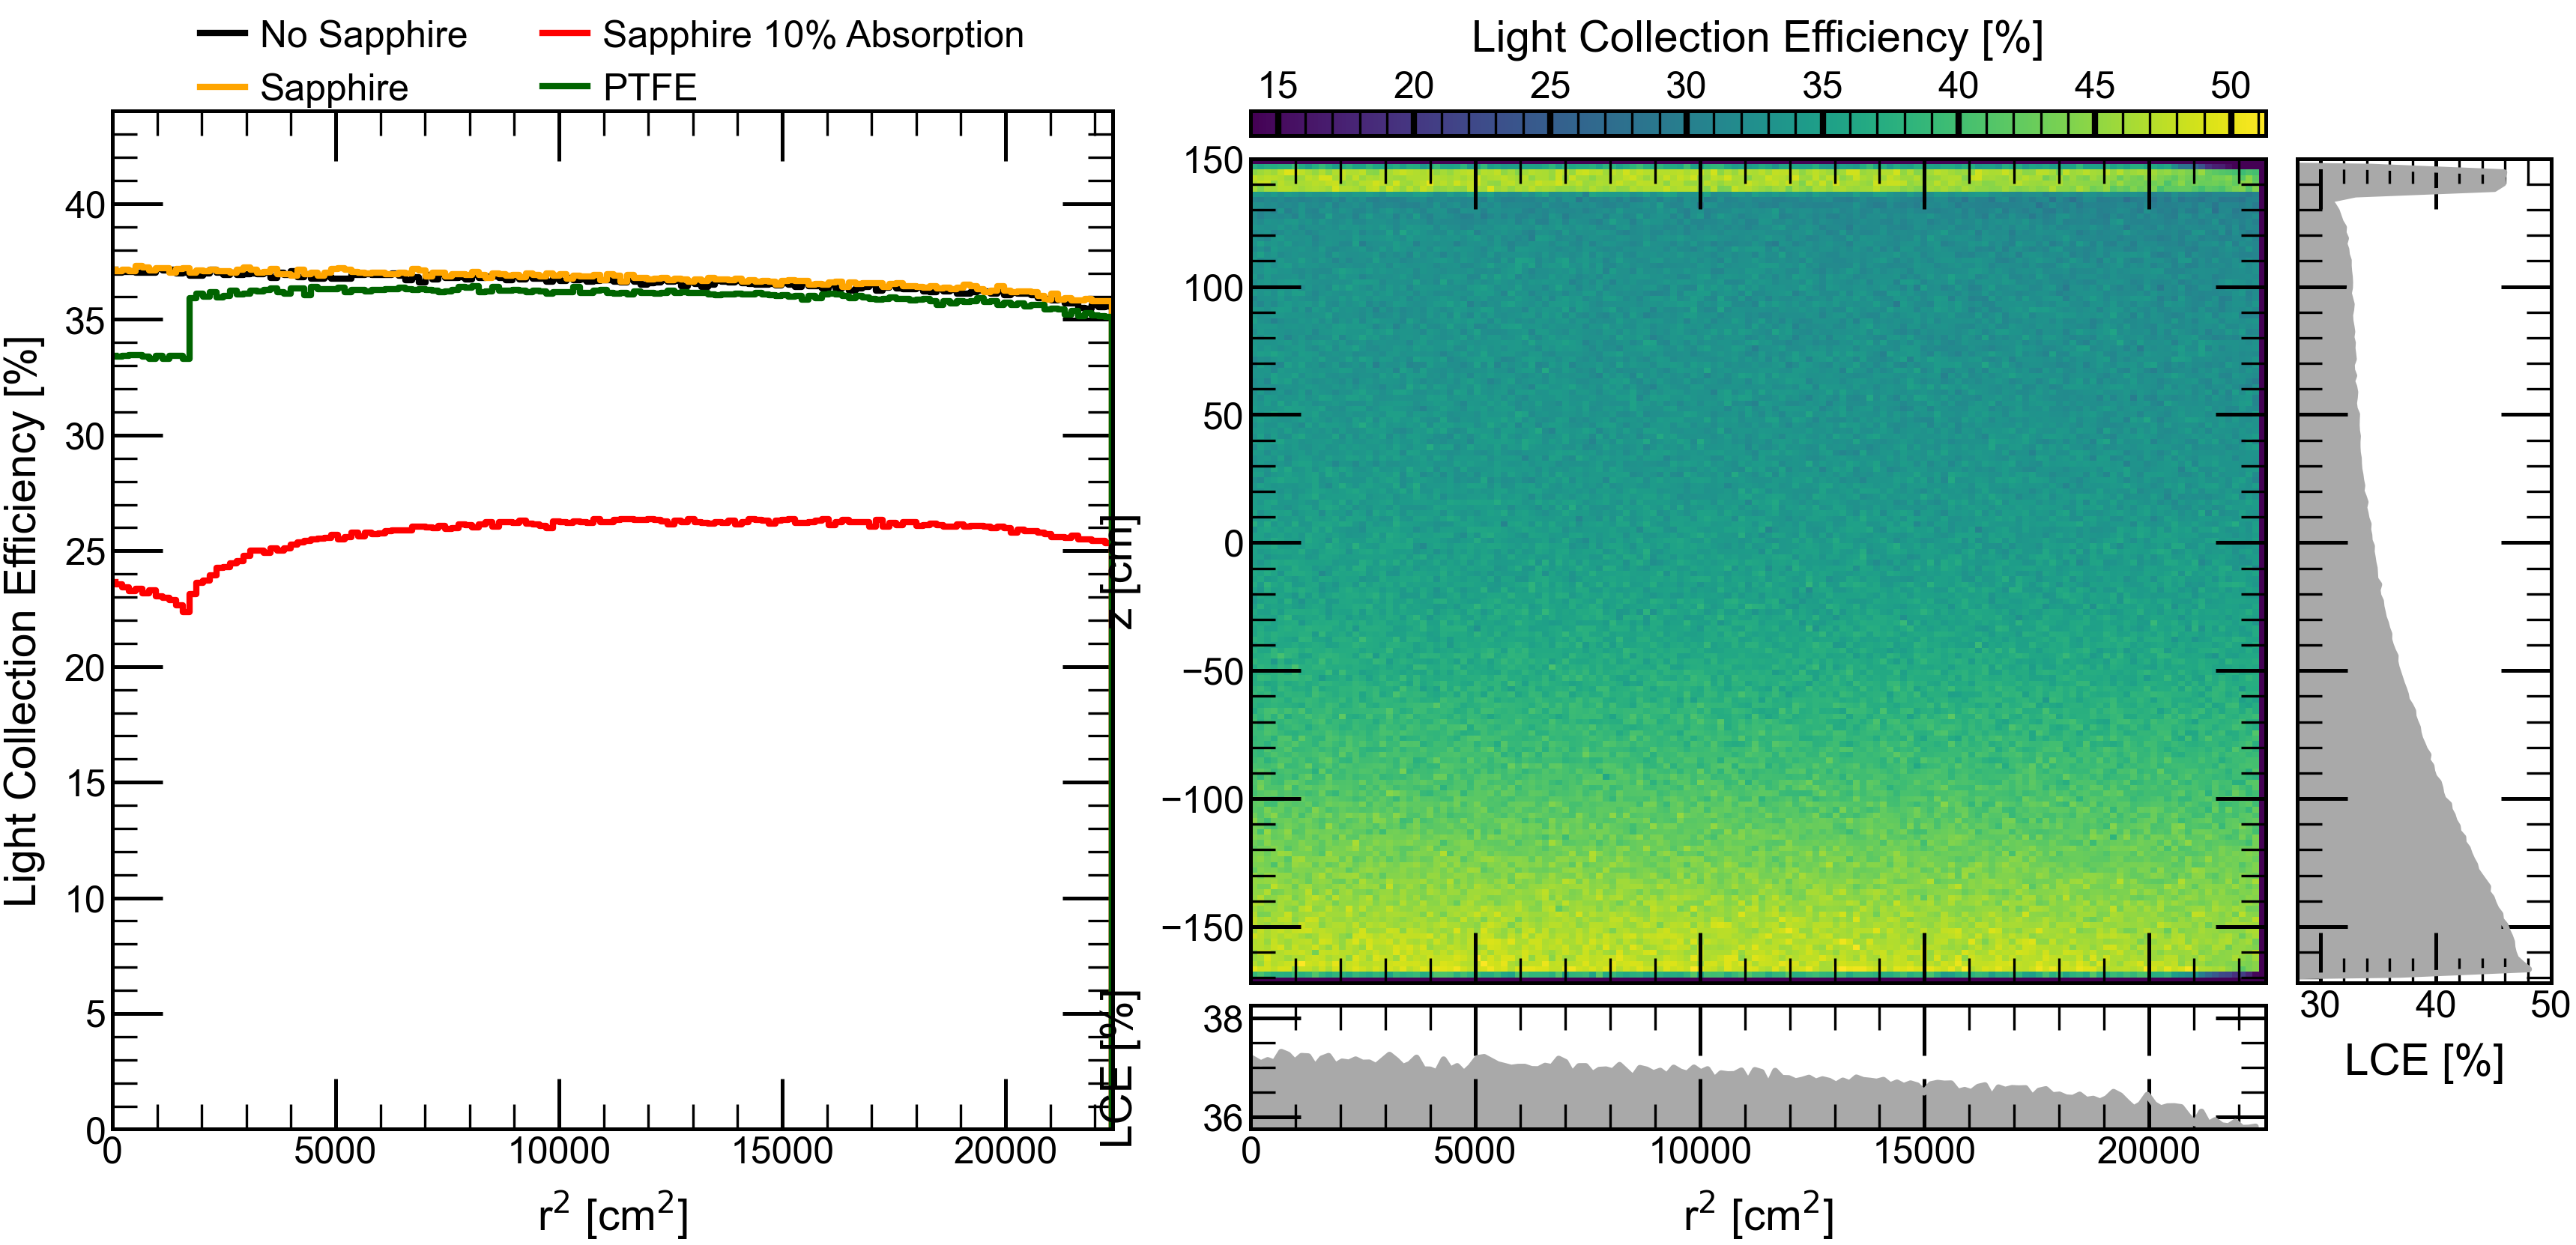

In [48]:
import h5py

# Load maps and compute 1D projections
hdfSaph = h5py.File("data/g1mapSapphire.hdf5", "r")
LCEbinsrad = hdfSaph["bins"]["0"][:]
LCEbinsz = hdfSaph["bins"]["1"][:]
LCEmap = hdfSaph["templates"]["g1mapSapphire"][:]/0.4*100

hdfSaph30 = h5py.File("data/g1mapSapphire10.hdf5", "r")
LCEmapSaph30 = hdfSaph30["templates"]["g1mapSapphire10"][:]/0.4*100

hdfLXe = h5py.File("data/g1mapLXe.hdf5", "r")
LCEmapLXe = hdfLXe["templates"]["g1mapLXe"][:]/0.4*100

hdfPTFE = h5py.File("data/g1mapPTFE.hdf5", "r")
LCEmapPTFE = hdfPTFE["templates"]["g1mapPTFE"][:]/0.4*100

LCEbinsradcenter = (LCEbinsrad[:-1] + LCEbinsrad[1:]) / 2
LCEbinszcenter = (LCEbinsz[:-1] + LCEbinsz[1:]) / 2

val_rad_LXe = LCEmapLXe.mean(axis=1)
val_rad_Saph = LCEmap.mean(axis=1)
val_rad_Saph30 = LCEmapSaph30.mean(axis=1)
val_rad_PTFE = LCEmapPTFE.mean(axis=1)

# Combined figure: left = 1D radial comparisons, right = 2D map with projections
fig = plt.figure(figsize=(14, 6))
outer_gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.3], wspace=0.12)

# Left: radial comparisons (1D)
ax_left = fig.add_subplot(outer_gs[0, 0])
ax_left.step(LCEbinsradcenter/100, val_rad_LXe, linewidth=2, color='black', label="No Sapphire")
ax_left.step(LCEbinsradcenter/100, val_rad_Saph, linewidth=2, color='orange', label="Sapphire")
ax_left.step(LCEbinsradcenter/100, val_rad_Saph30, linewidth=2, color='red', label="Sapphire 10% Absorption")
ax_left.step(LCEbinsradcenter/100, val_rad_PTFE, linewidth=2, color='darkgreen', label="PTFE")
ax_left.set_xlabel(r"r$^2$ [cm$^2$]")
ax_left.set_ylabel("Light Collection Efficiency [%]")
ax_left.set_xlim(0,22400)
ax_left.set_ylim(0,44)
ax_left.legend(prop={'size': 12}, loc="upper center", bbox_to_anchor=(0.5, 1.12), ncol=2)

# Right: 2D map with projections (use nested gridspec)
right_gs = outer_gs[0,1].subgridspec(3,2, width_ratios=[4,1], height_ratios=[0.12,4,0.6], wspace=0.05, hspace=0.07)
ax_map = fig.add_subplot(right_gs[1,0])
ax_cb = fig.add_subplot(right_gs[0,0])
ax_proj = fig.add_subplot(right_gs[1,1])
ax_rad = fig.add_subplot(right_gs[2,0], sharex=ax_map)

cmap = mpl.cm.viridis.copy()
mesh = ax_map.pcolormesh(LCEbinsrad/100, LCEbinsz/10, LCEmap.T, cmap=cmap, vmin=14)
cbar = fig.colorbar(mesh, cax=ax_cb, orientation='horizontal')
ax_cb.xaxis.set_label_position('top')
ax_cb.xaxis.set_ticks_position('top')
ax_cb.tick_params(axis="x", which="major", length=8, width=2.0)
cbar.set_label('Light Collection Efficiency [%]')

ax_map.set_ylabel("z [cm]")
ax_map.xaxis.set_tick_params(labelleft=False)
ax_map.set_ylim(-172,150)
ax_map.set_xlim(0,22600)

# vertical projection (z-averaged) on the right
LCEmap_zproj = LCEmap.mean(axis=0)
ax_proj.plot(LCEmap_zproj, LCEbinszcenter/10, linewidth=2, color='darkgray', alpha=1)
ax_proj.fill_betweenx(LCEbinszcenter/10, LCEmap_zproj, x2=0, color='darkgray', alpha=1)
ax_proj.set_xlabel("LCE [%]")
ax_proj.set_xlim(28,50)
ax_proj.set_ylim(-172,150)
ax_proj.yaxis.set_ticklabels([])

# radial projection below the map
LCEmap_radproj = LCEmap.mean(axis=1)
ax_rad.plot(LCEbinsradcenter/100, LCEmap_radproj, linewidth=2, color='darkgray', alpha=1)
ax_rad.fill_between(LCEbinsradcenter/100, LCEmap_radproj, color='darkgray', alpha=1)
ax_rad.set_ylabel("LCE [%]")
ax_rad.set_xlabel(r"r$^2$ [cm$^2$]")
ax_rad.set_ylim(35.75,38.25)

fig.align_ylabels([ax_map, ax_rad])

plt.show()

### Low Energy ER Spectrum (materials + intrinsics)

In [ ]:
%run gen_energy_plots.py FIG_DOUBLE[0] FIG_DOUBLE[1]

usage: gen_energy_plots.py [-h] fig_height fig_width
gen_energy_plots.py: error: argument fig_height: invalid float value: 'FIG_DOUBLE[0]'


SystemExit: 2

### High Energy ER Spectrum

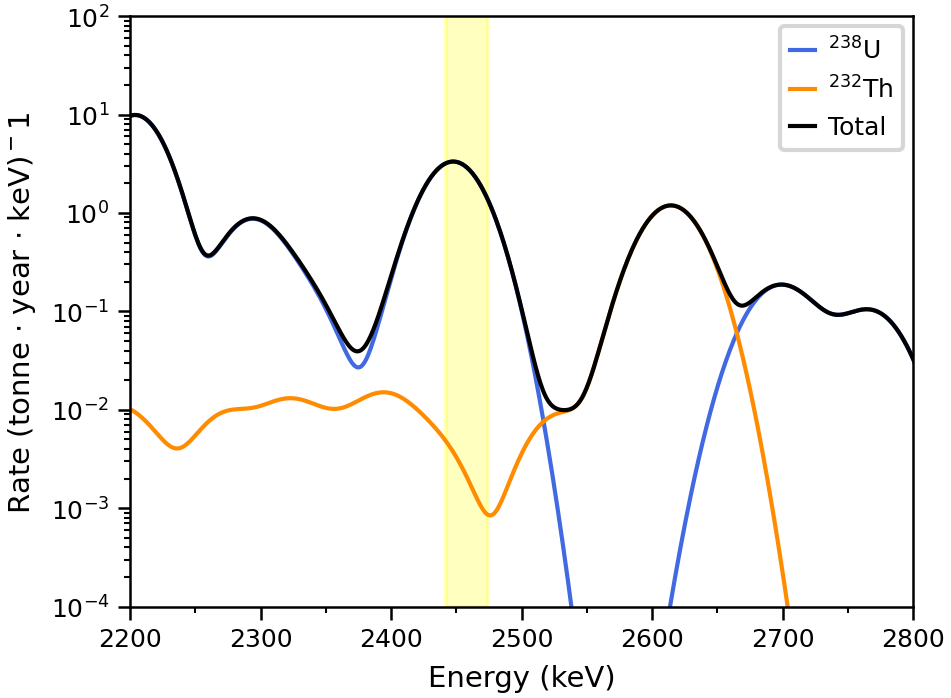

In [ ]:
# ----------
# Functions
# ----------
def energy_res(energy, a_res=0.317, b_res=1.7):
    resolution = a_res*np.sqrt(energy)+b_res*10**-3*energy
    return resolution

def gaussian(x, mu, sig):
    return (
        1.0 / (np.sqrt(2.0 * np.pi) * sig) * np.exp(-np.power((x - mu) / sig, 2.0) / 2)
    )

def apply_energy_smear(hist, e_edges, bins=1000):

    bw   = e_edges[1] - e_edges[0]
    xs = np.linspace(e_edges[0], e_edges[-1], bins)
    smeared_array = np.zeros(len(xs))

    for idx, val in enumerate(hist):
        E_val = e_edges[idx]
        if E_val != 0:
            sigma = energy_res(E_val)
            fun   = gaussian(xs, E_val, sigma) * val * bw
            smeared_array = np.add(smeared_array,fun)

    return xs, smeared_array

# -----
# Main
# -----
dirpath  = PROJECT_ROOT / "common_plots" / "data"
npfile   = np.load(dirpath / "high_e_inner.npz")
e_edges  = npfile["e_edges"]
hist_arr = npfile["hist_arr"]

spectra = []
for idx in range(0,2):
    hist = hist_arr[idx]
    spectra.append(hist)

total = np.sum(spectra, axis=0)

fig, ax = plt.subplots()

labels = ["U238", "Th232"]
for idx, spectrum in enumerate(spectra[:2]):
    xs, smeared_hist = apply_energy_smear(spectrum, e_edges)
    ax.plot(
        xs, 
        smeared_hist , 
        label=isotope_dict[labels[idx]]["tex"], 
        color=isotope_dict[labels[idx]]["color"])

xs, smeared_hist = apply_energy_smear(total, e_edges)
ax.plot(xs, smeared_hist, label="Total", color='black')
ax.set_xlabel("Energy (keV)")
ax.set_ylabel(rf"Rate (tonne $\cdot$ year $\cdot$ keV)$^{-1}$")
ax.set_yscale("log")
ax.set_ylim(1e-4, 1e2)
ax.set_xlim(2200, 2800)
xticks = np.arange(2200, 2800, 50)
ax.set_xticks(xticks, minor=True)
ax.axvspan(2458-16, 2458+16, alpha=0.25, color='yellow')
#ax.text(3.2, 70, r'WIMP ROI', fontsize=8)
ax.legend(
loc="upper right",
ncol=1,
frameon=True,
fontsize=6,
columnspacing=0.3,
handlelength=1,
handletextpad=0.5,
borderpad=0.4,
)
plt.tight_layout();

In [56]:
FIG_DOUBLE[0]

6.69

## ER NR Efficiency

In [195]:
import h5py
hdf = h5py.File("data/sens_plot_data.hdf5", "r")

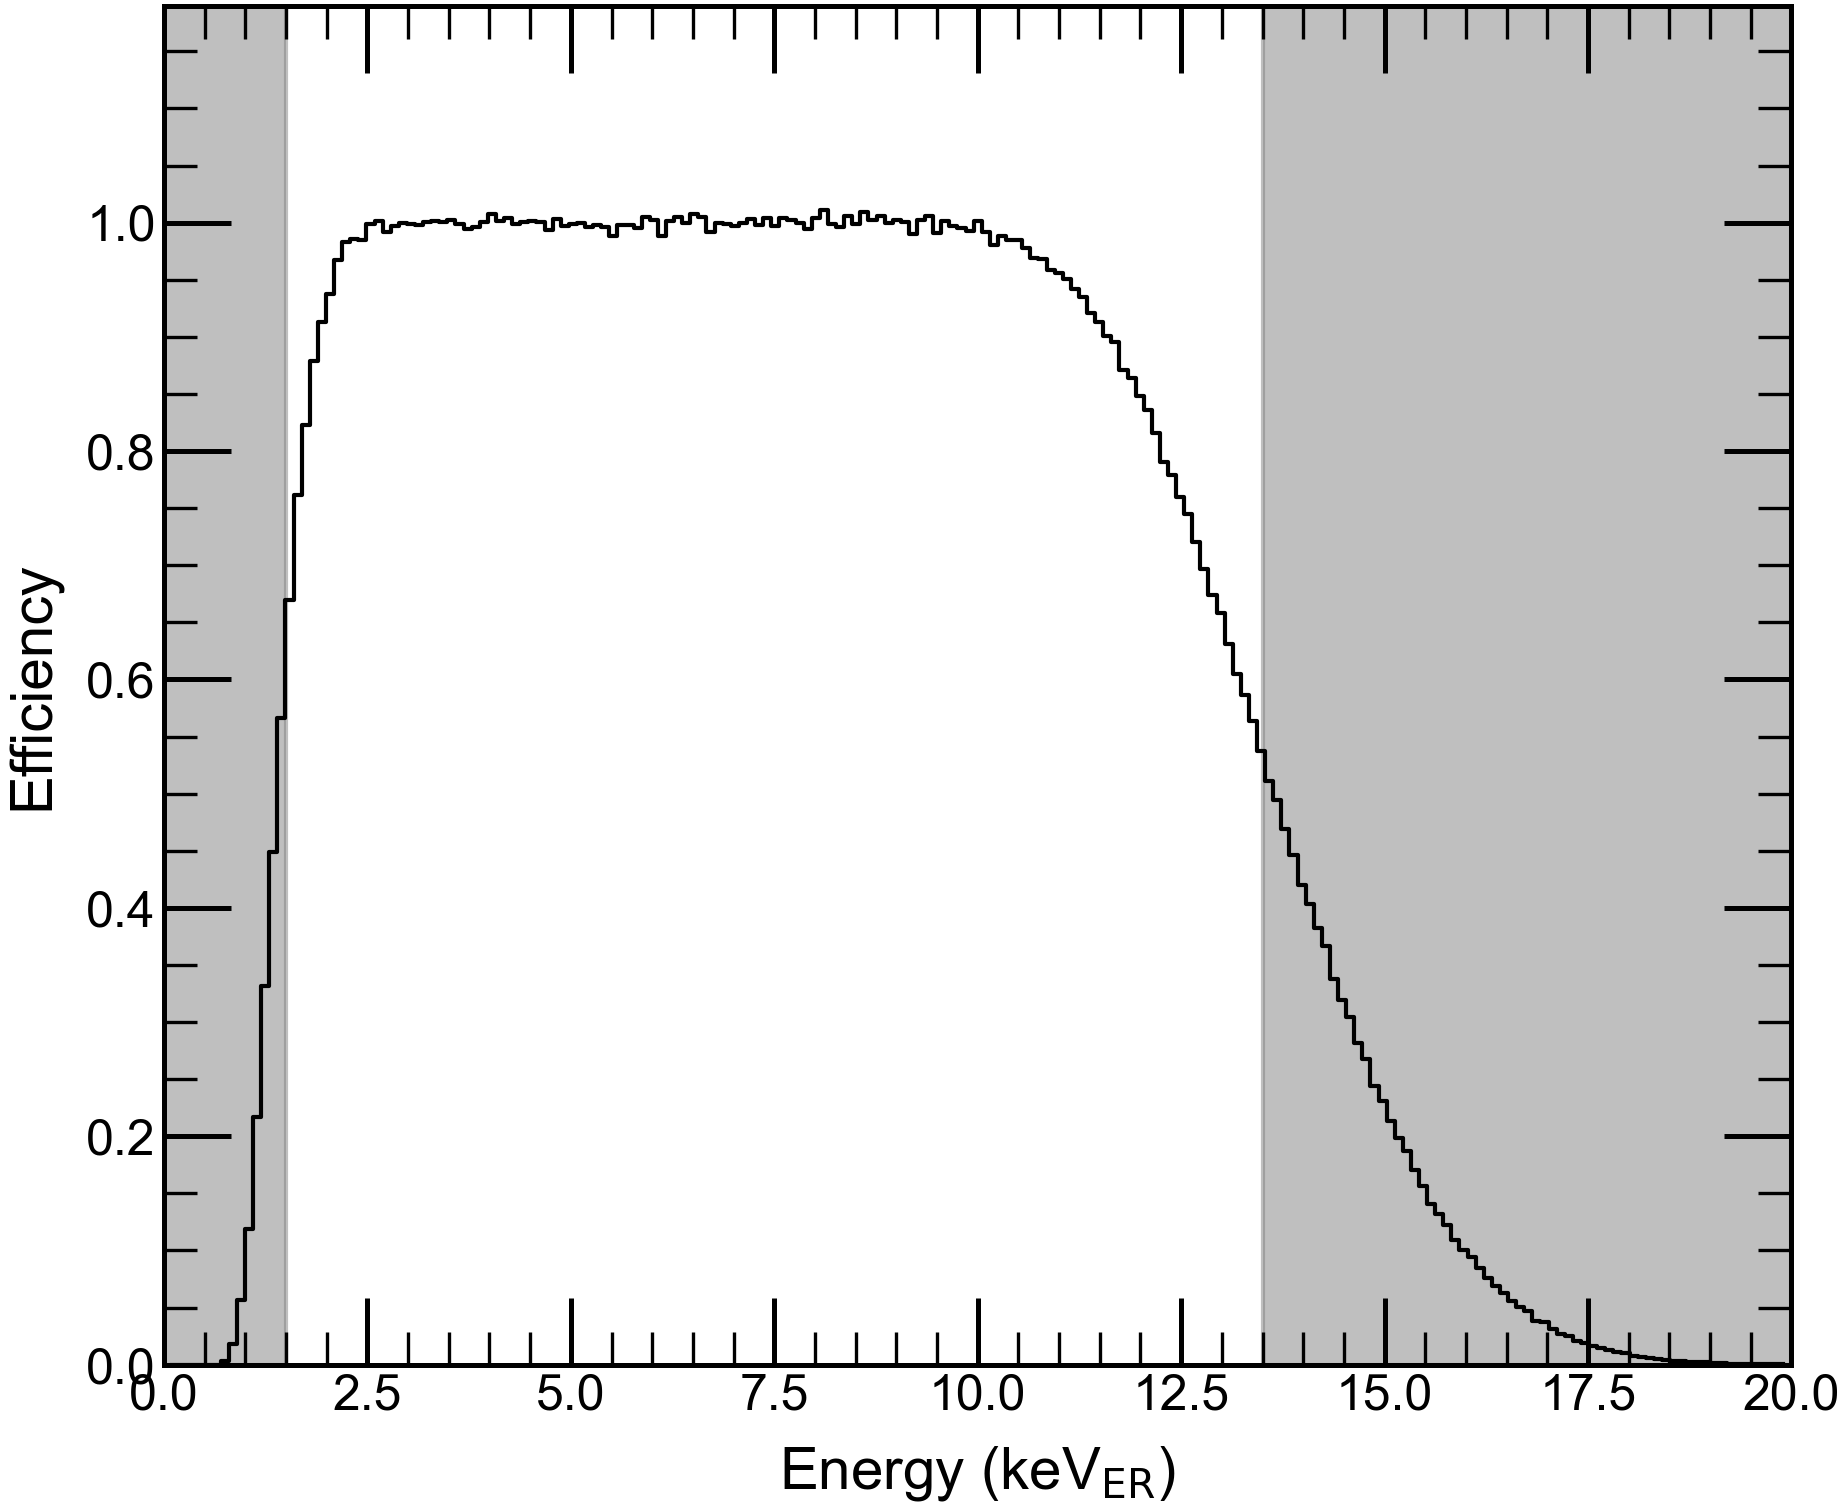

In [50]:
h = hdf["efficiency_ER"]
energy_05_low = 1.5
energy_05_high = 13.5

fig = plt.figure(figsize=(7, 6))

plt.step(h[0], h[1], where="post", color="black")

plt.axvspan(0, energy_05_low, color="gray", alpha=0.5, zorder=0)
plt.axvspan(energy_05_high, 20, color="gray", alpha=0.5, zorder=0)

plt.xlim(0, 20)
plt.ylim(0, 1.19)

plt.ylabel("Efficiency")
plt.xlabel("Energy (keV$_{\mathrm{ER}}$)")

plt.show()

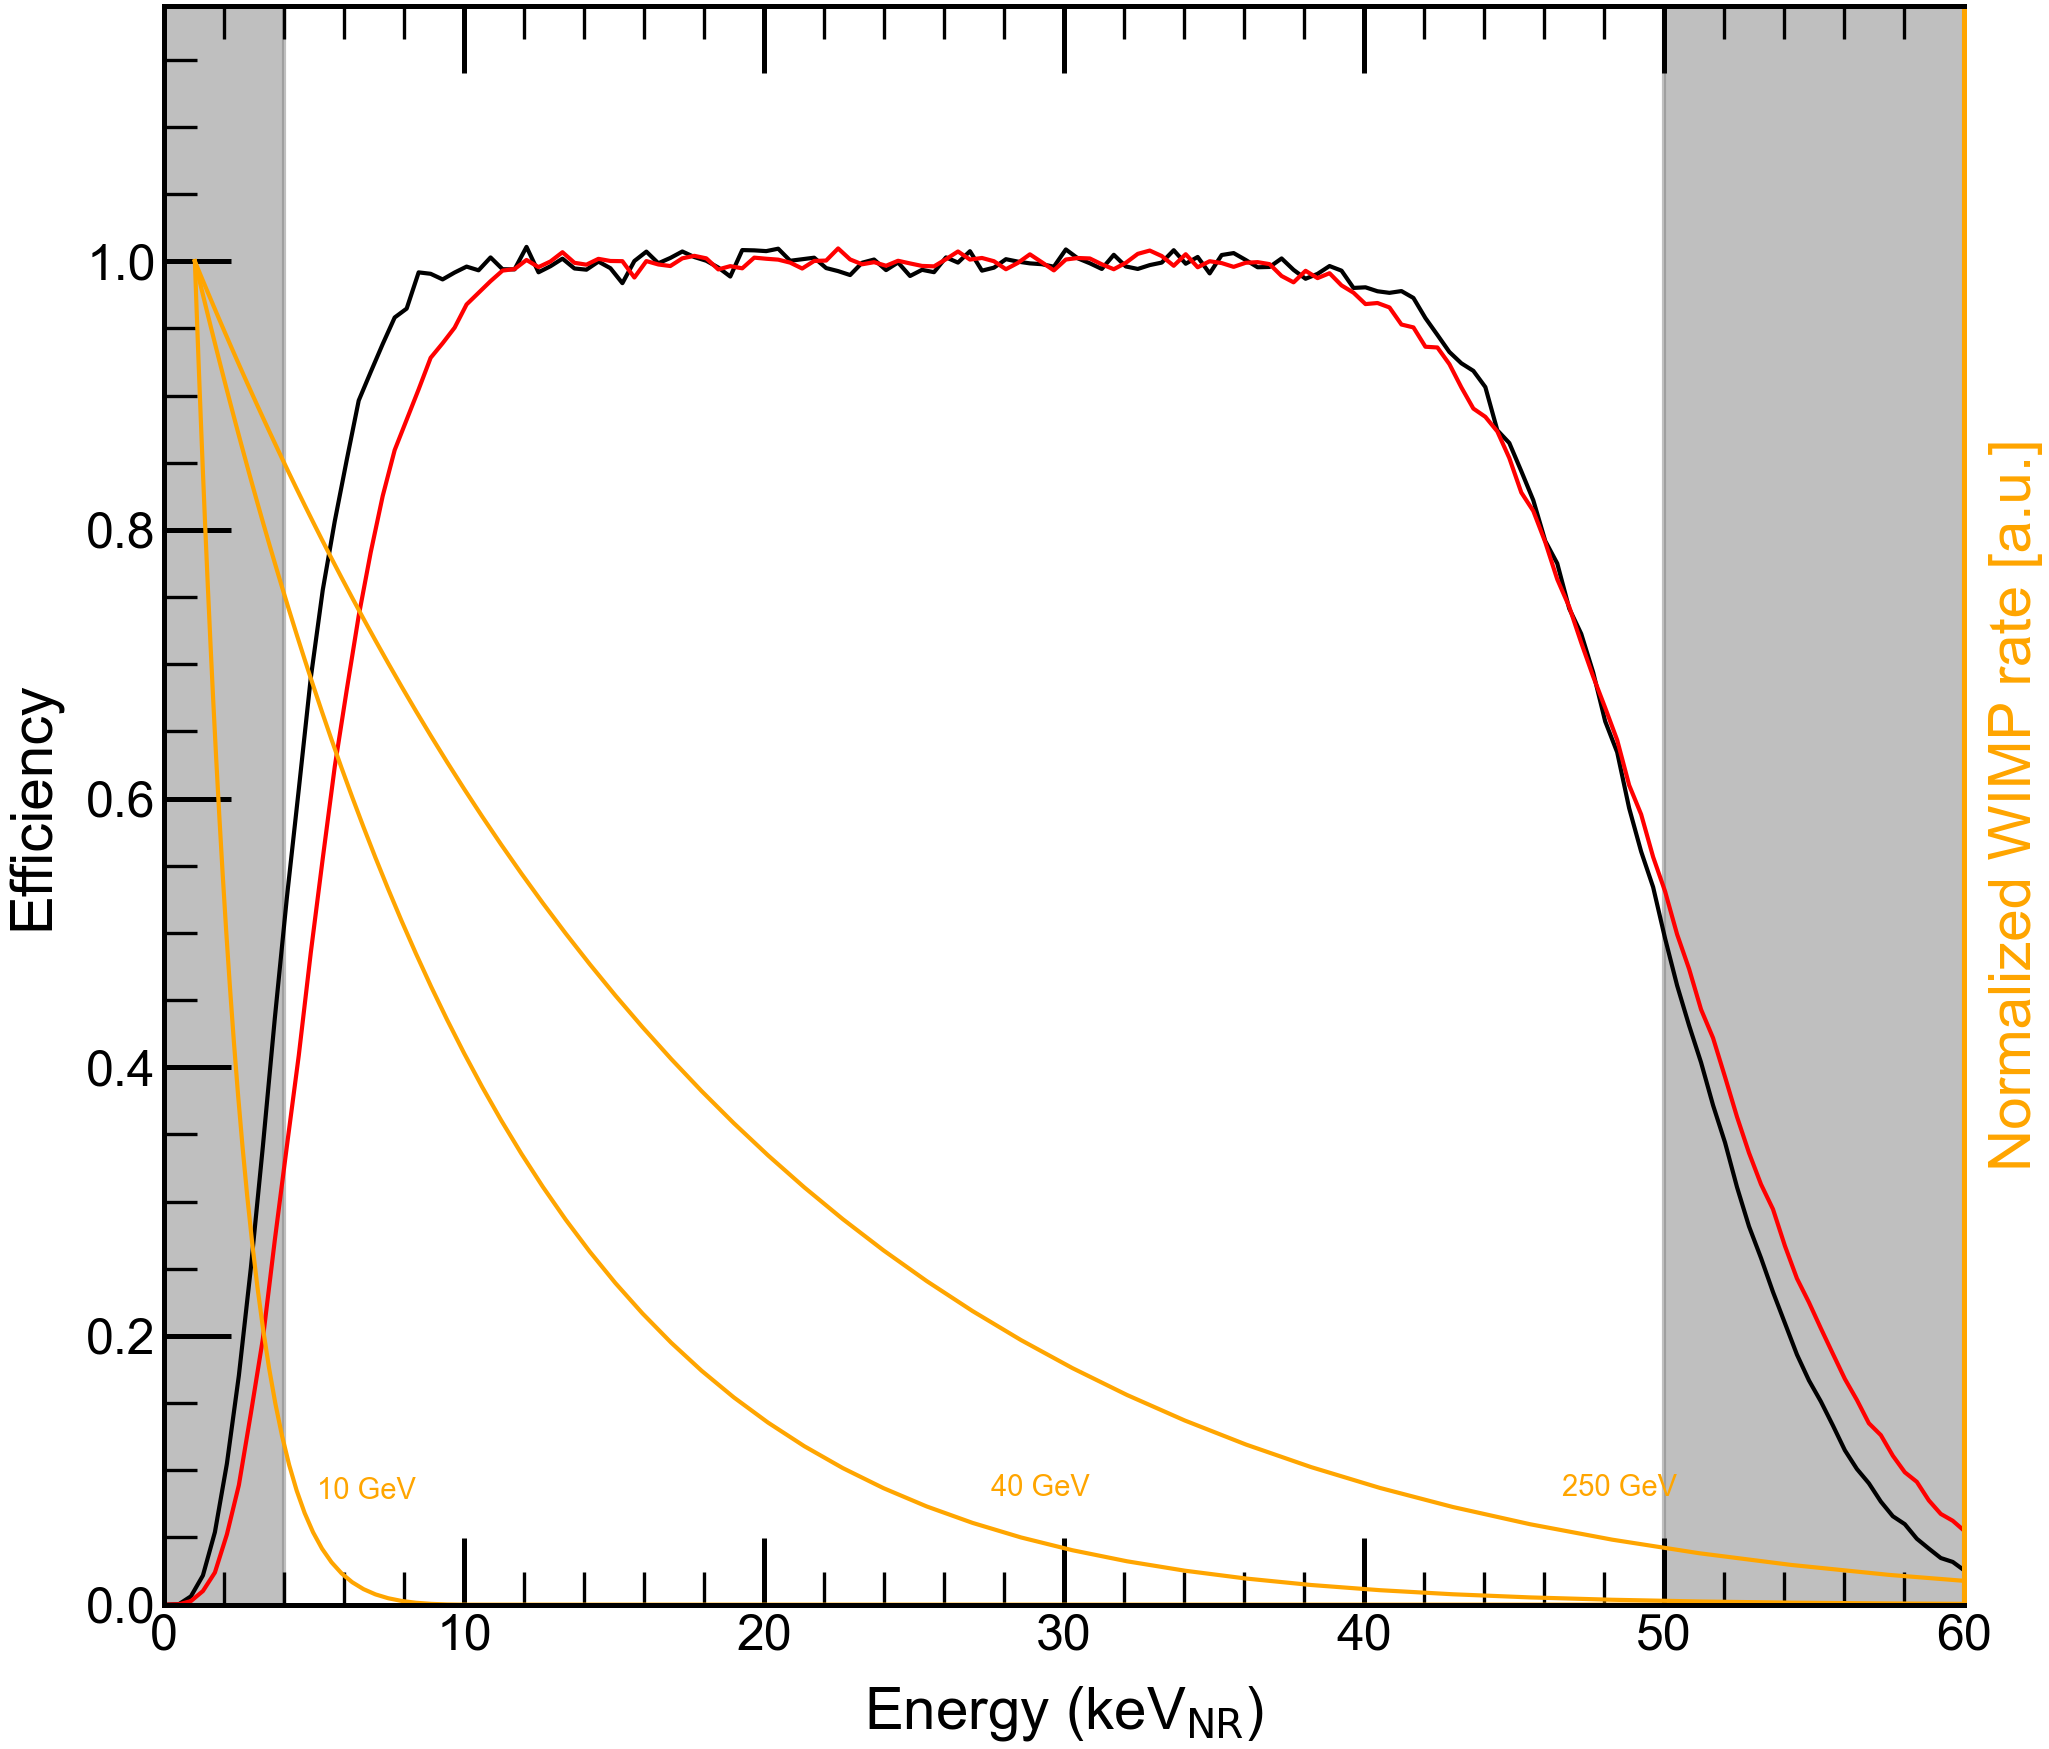

In [51]:
h = hdf["efficiency_NR"]
h_10p = hdf["efficiency_NR_10p"]

energy_05_low = 4
energy_05_high = 50

fig = plt.figure(figsize=(7, 6))

ax1 = plt.gca()
ax1.plot(h[0], h[1], ls="-", color="black", label="Efficiency")
ax1.plot(h_10p[0], h_10p[1], ls="-", color="red", label="Efficiency 10\% abs.")
ax1.set_ylabel("Efficiency")
ax1.set_ylim(0, 1.19)

# Create a second y-axis on the right for the WIMP spectra
ax2 = ax1.twinx()
ax2.spines["right"].set_color("orange")
ax2.yaxis.label.set_color("orange")
#ax2.tick_params(axis="y", colors="orange")
ax2.set_yticklabels([])
ax2.set_yticks([])
ax2.set_ylabel("Normalized WIMP rate [a.u.]", color="orange")
ax2.set_ylim(0, 1.19)

mws = [10, 40, 250]
# Put WIMP spectra on the right axis
for mw in mws:
    x,y = hdf[f"WIMP_rate_{mw}GeV"][:]
    ax2.plot(x, y, "-", color="orange")
    # find energy where rate goes below 0.1
    idx = np.where(y < 0.1)[0][0]
    ax2.text(x[idx]*1.15, y[idx], f"{mw} GeV", color="orange", va="center", ha="left")

ax1.set_xlim(0, 60)
ax1.set_xlabel("Energy (keV$_{\mathrm{NR}}$)")

ax1.axvspan(0, energy_05_low, color="gray", alpha=0.5, zorder=0)
ax1.axvspan(energy_05_high, 60, color="gray", alpha=0.5, zorder=0)

plt.tight_layout()

plt.show()

C:\Users\LAlth\AppData\Local\Temp\ipykernel_28532\3029422661.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


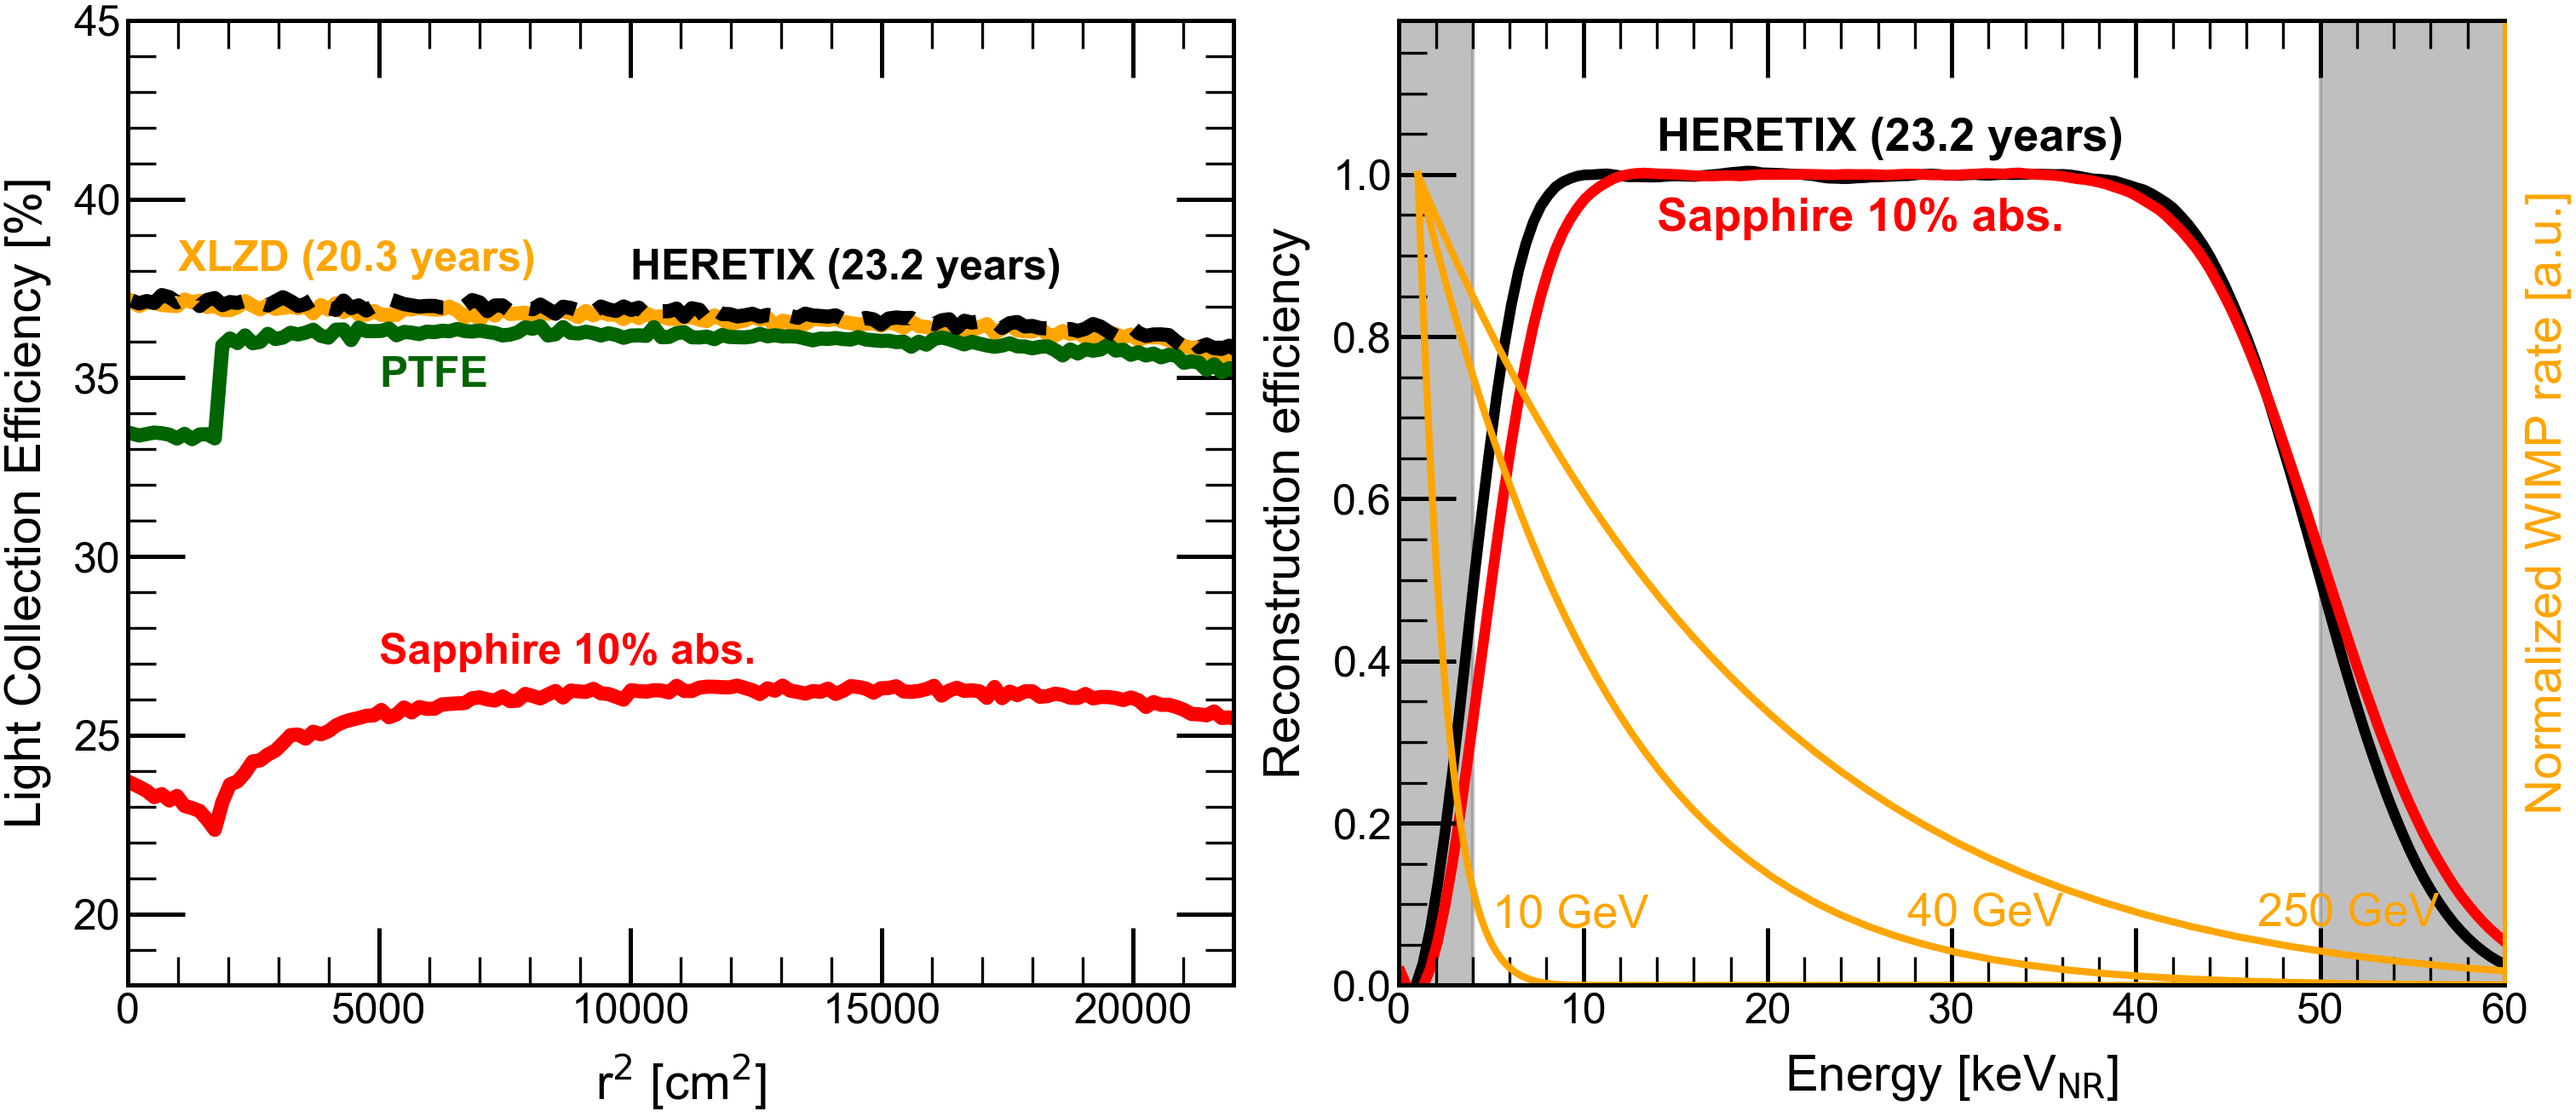

In [208]:
h = hdf["efficiency_NR"]
h_10p = hdf["efficiency_NR_10p"]

energy_05_low = 4
energy_05_high = 50

valueLCEarray1dradSaph = LCEmap.mean(axis=1)

hdfLCESapphire10 = h5py.File("data/g1mapSapphire10.hdf5", "r")
LCEmapSaph10 = hdfLCESapphire10["templates"]["g1mapSapphire10"][:]/0.4*100
valueLCEarray1dradSaph10 = LCEmapSaph10.mean(axis=1)

hdfLCELXe = h5py.File("data/g1mapLXe.hdf5", "r")
LCEmapLXe = hdfLCELXe["templates"]["g1mapLXe"][:]/0.4*100
valueLCEarray1drad = LCEmapLXe.mean(axis=1)

hdfLCEPTFE = h5py.File("data/g1mapPTFE.hdf5", "r")
LCEmapPTFE = hdfLCEPTFE["templates"]["g1mapPTFE"][:]/0.4*100
valueLCEarray1dradPTFE = LCEmapPTFE.mean(axis=1)

fig = plt.figure(figsize=(12,5))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1], wspace=0.15)

ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])

wl = 5
order = 2
valueLCEarray1drad_smooth = savgol_filter(valueLCEarray1drad, wl, order)
valueLCEarray1dradSaph_smooth = savgol_filter(valueLCEarray1dradSaph, wl, order)
valueLCEarray1dradSaph10_smooth = savgol_filter(valueLCEarray1dradSaph10, wl, order)
valueLCEarray1dradPTFE_smooth = savgol_filter(valueLCEarray1dradPTFE, wl, order)

ax0.plot(LCEbinsradcenter/100,valueLCEarray1drad, linewidth=4, color='orange', ls='-', label="XLZD")
ax0.plot(LCEbinsradcenter/100,valueLCEarray1dradPTFE, linewidth=4, color='darkgreen', label="H-TPC (PTFE)")
ax0.plot(LCEbinsradcenter/100,valueLCEarray1dradSaph, linewidth=4, color='black', ls="--", label="H-TPC (Sapphire)")
ax0.plot(LCEbinsradcenter/100,valueLCEarray1dradSaph10, linewidth=4, color='red', label="H-TPC (Sapphire, 10% Abs.)")

ax0.set_xlabel(r"r$^2$ [cm$^2$]")
ax0.set_ylabel("Light Collection Efficiency [%]")
ax0.set_xlim(0,22000)
ax0.set_ylim(18,45)
#ax0.legend(prop={'size': 11},loc="upper center", bbox_to_anchor=(0.5, 0.95), ncol=2)

ax1 = plt.gca()
# smooth the efficiency curves for better visualization
h_smooth = savgol_filter(h[1], 21, 3)
h_10p_smooth = savgol_filter(h_10p[1], 21, 3)
ax1.plot(h[0], h_smooth, ls="-", color="black", label="Efficiency", lw=3, zorder=1)
ax1.plot(h_10p[0], h_10p_smooth, ls="-", color="red", label="Efficiency 10\% abs.", lw=3, zorder=1)
ax1.set_ylabel("Reconstruction efficiency")
ax1.set_ylim(0, 1.19)

# Create a second y-axis on the right for the WIMP spectra
ax2 = ax1.twinx()
ax2.spines["right"].set_color("orange")
ax2.yaxis.label.set_color("orange")
#ax2.tick_params(axis="y", colors="orange")
ax2.set_yticklabels([])
ax2.set_yticks([])
ax2.set_ylabel("Normalized WIMP rate [a.u.]", color="orange")
ax2.set_ylim(0, 1.19)

mws = [10, 40, 250]
# Put WIMP spectra on the right axis
for mw in mws:
    x,y = hdf[f"WIMP_rate_{mw}GeV"][:]
    ax2.plot(x, y, "-", color="orange", lw=2, zorder=0)
    # find energy where rate goes below 0.1
    idx = np.where(y < 0.1)[0][0]
    ax2.text(x[idx]*1.15, y[idx], f"{mw} GeV", color="orange", va="center", ha="left", fontsize=13)

ax1.set_xlim(0, 60)
ax1.set_xlabel("Energy [keV$_{\mathrm{NR}}$]")

ax1.axvspan(0, energy_05_low, color="gray", alpha=0.5, zorder=0)
ax1.axvspan(energy_05_high, 60, color="gray", alpha=0.5, zorder=0)

ax0.text(1000, 38, "XLZD (20.3 years)", fontsize=12, fontweight="bold", color="orange")
ax0.text(10000, 37.75, "HERETIX (23.2 years)", fontsize=12, fontweight="bold", color="black")
ax0.text(5000, 34.75, "PTFE", fontsize=12, fontweight="bold", color="darkgreen")
ax0.text(5000, 27, "Sapphire 10% abs.", fontsize=12, fontweight="bold", color="red")

ax1.text(14, 1.03, "HERETIX (23.2 years)", fontsize=13, fontweight="bold", color="black")
ax1.text(14, 0.93, "Sapphire 10% abs.", fontsize=13, fontweight="bold", color="red")

plt.tight_layout()
plt.savefig("efficiency_lce_nr.png", bbox_inches="tight", dpi=300)
plt.show()

## WIMP sensitivity limits

In [98]:
import h5py
hdf = h5py.File("data/sens_plot_data.hdf5", "r")

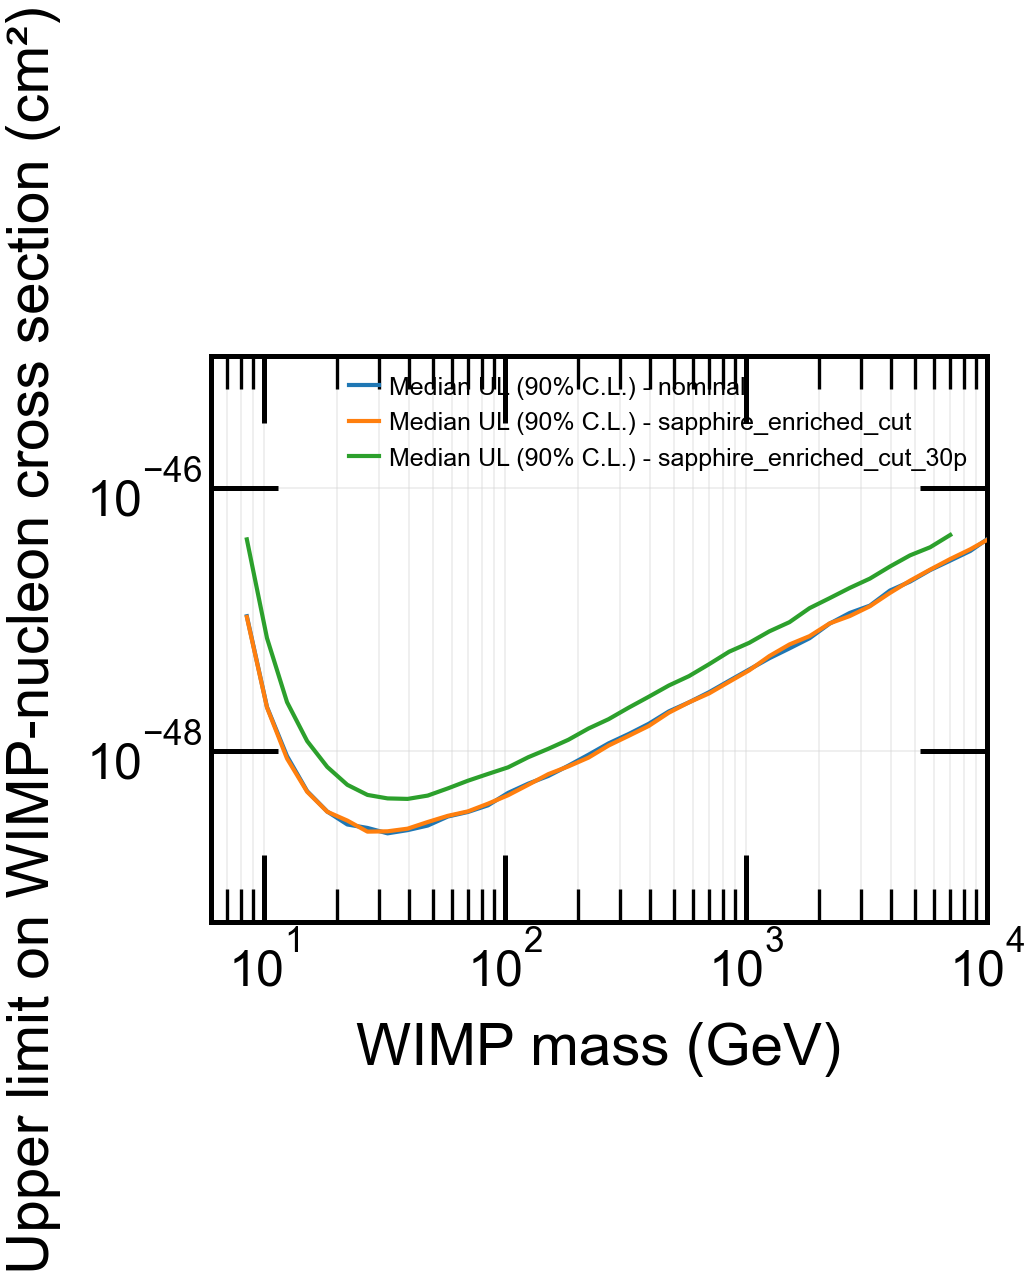

In [9]:
# Plot the limits as a function of WIMP mass
ref_xsec = 1e-48 # cm^2

fig = plt.figure()

keys = ["nominal", "sapphire_enriched_cut", "sapphire_enriched_cut_30p"]

for key in keys:
    if key in hdf:
        masses, ul_median = hdf[key][:]
        plt.plot(masses, ul_median, label=f"Median UL (90% C.L.) - {key}", zorder=3)

plt.ylim(5e-50, 1e-45)
plt.xlim(6, 1e4)
plt.xscale("log")
plt.yscale("log")

plt.xlabel("WIMP mass (GeV)")
plt.ylabel("Upper limit on WIMP-nucleon cross section (cm²)")

plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)

plt.show()

### 0nu2B Sensitivity

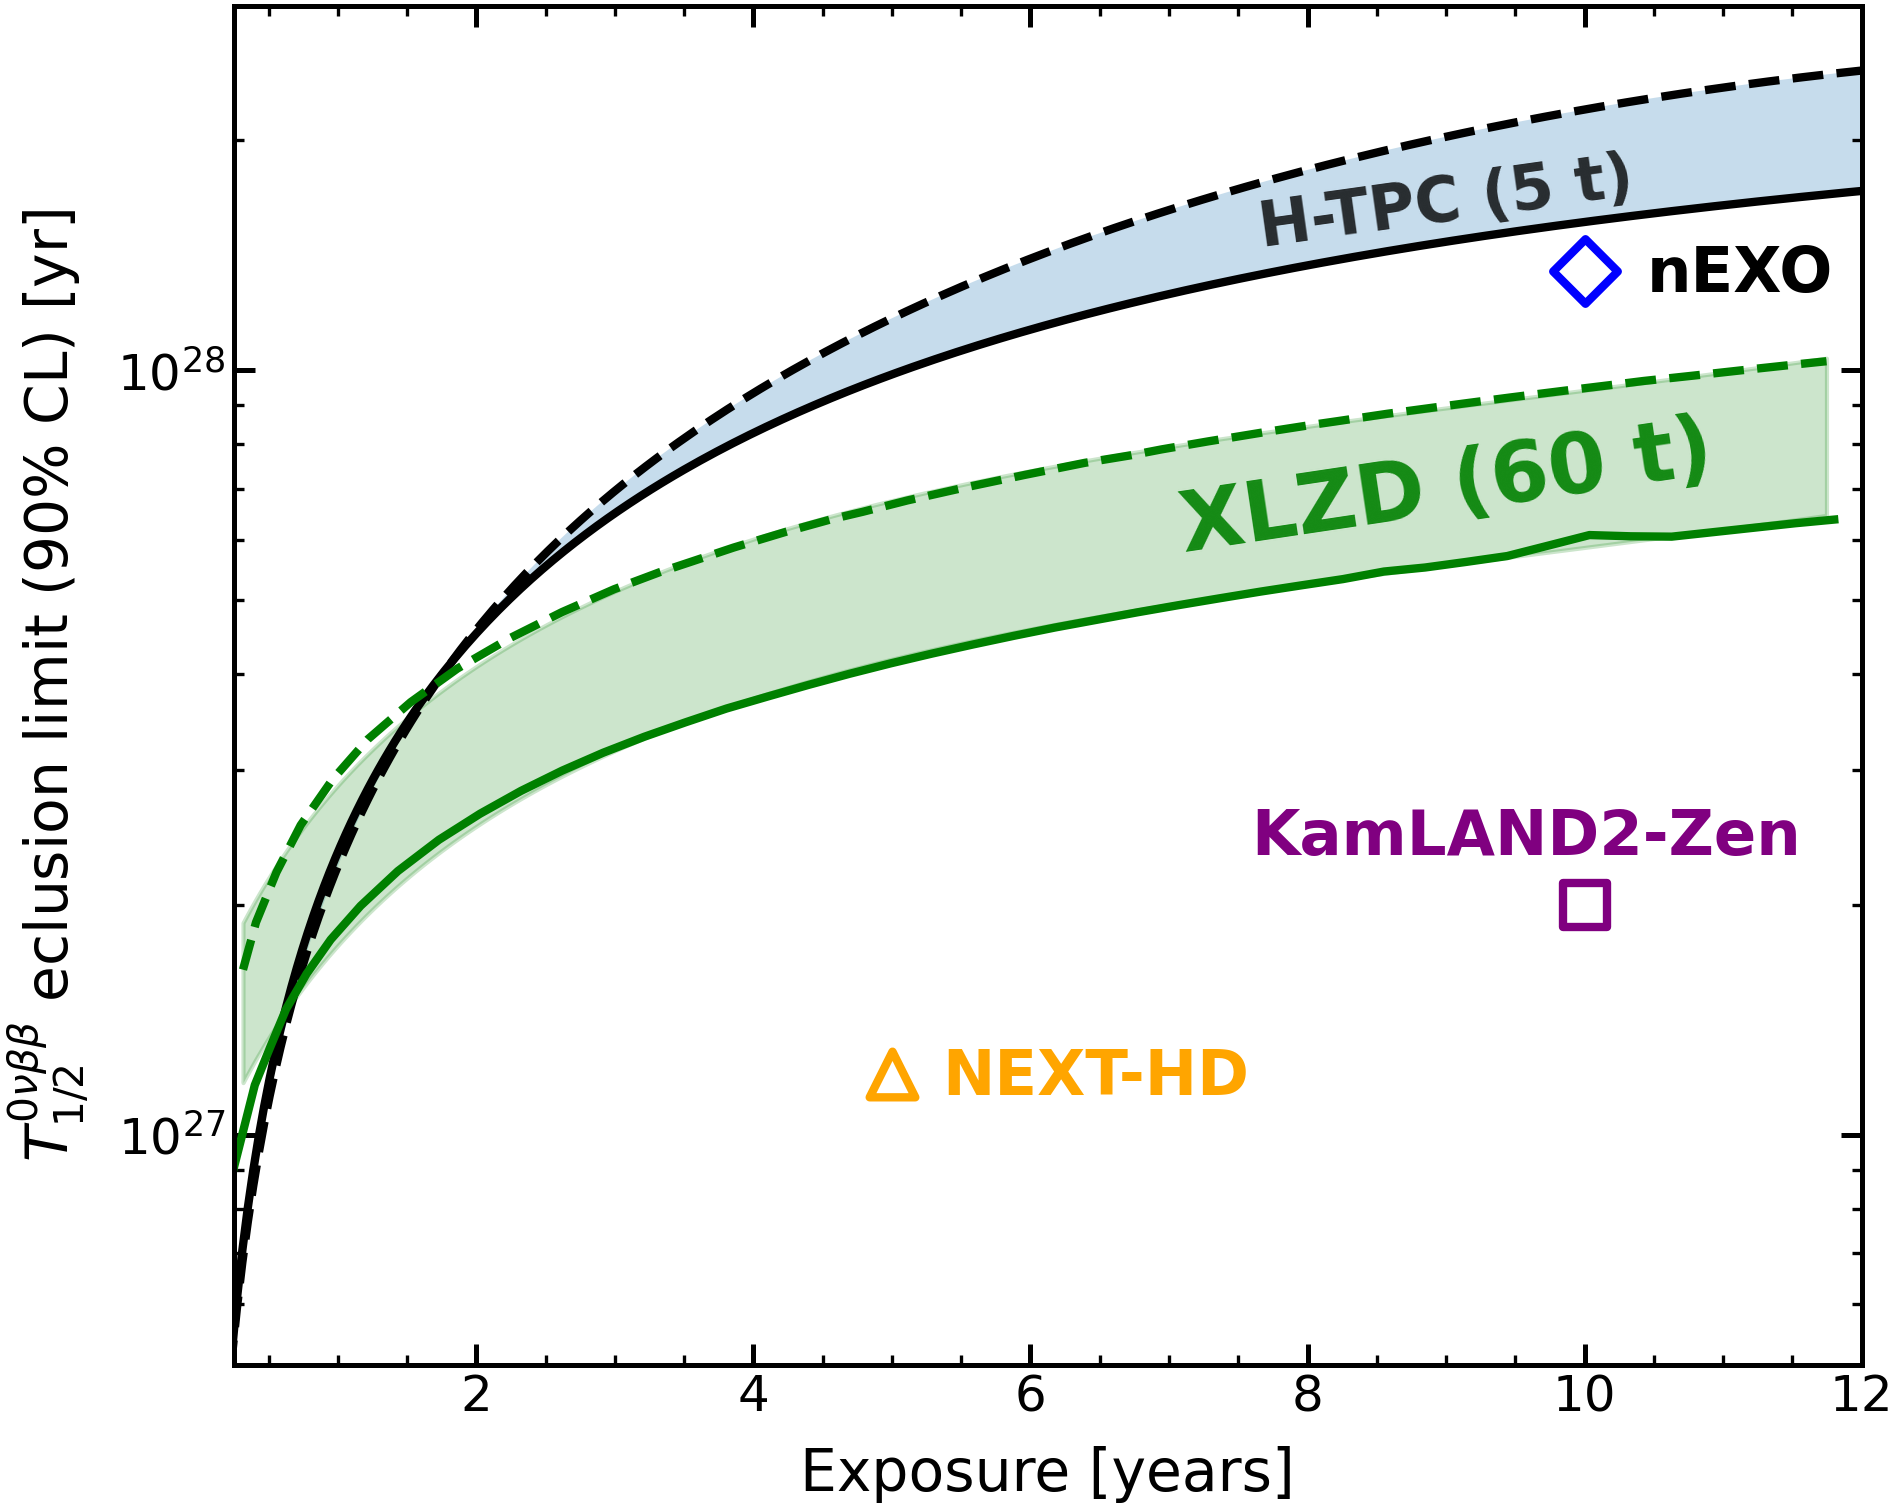

In [8]:
%run 0nu2b_exclusionplot.py

### Combined Sensitivity Plot

C:\L_Althueser\git\HermeticTPC\common_plots\twopanel_sensitivities.py:14: DeprecationWarning: Please import `gaussian_filter1d` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.filters import gaussian_filter1d


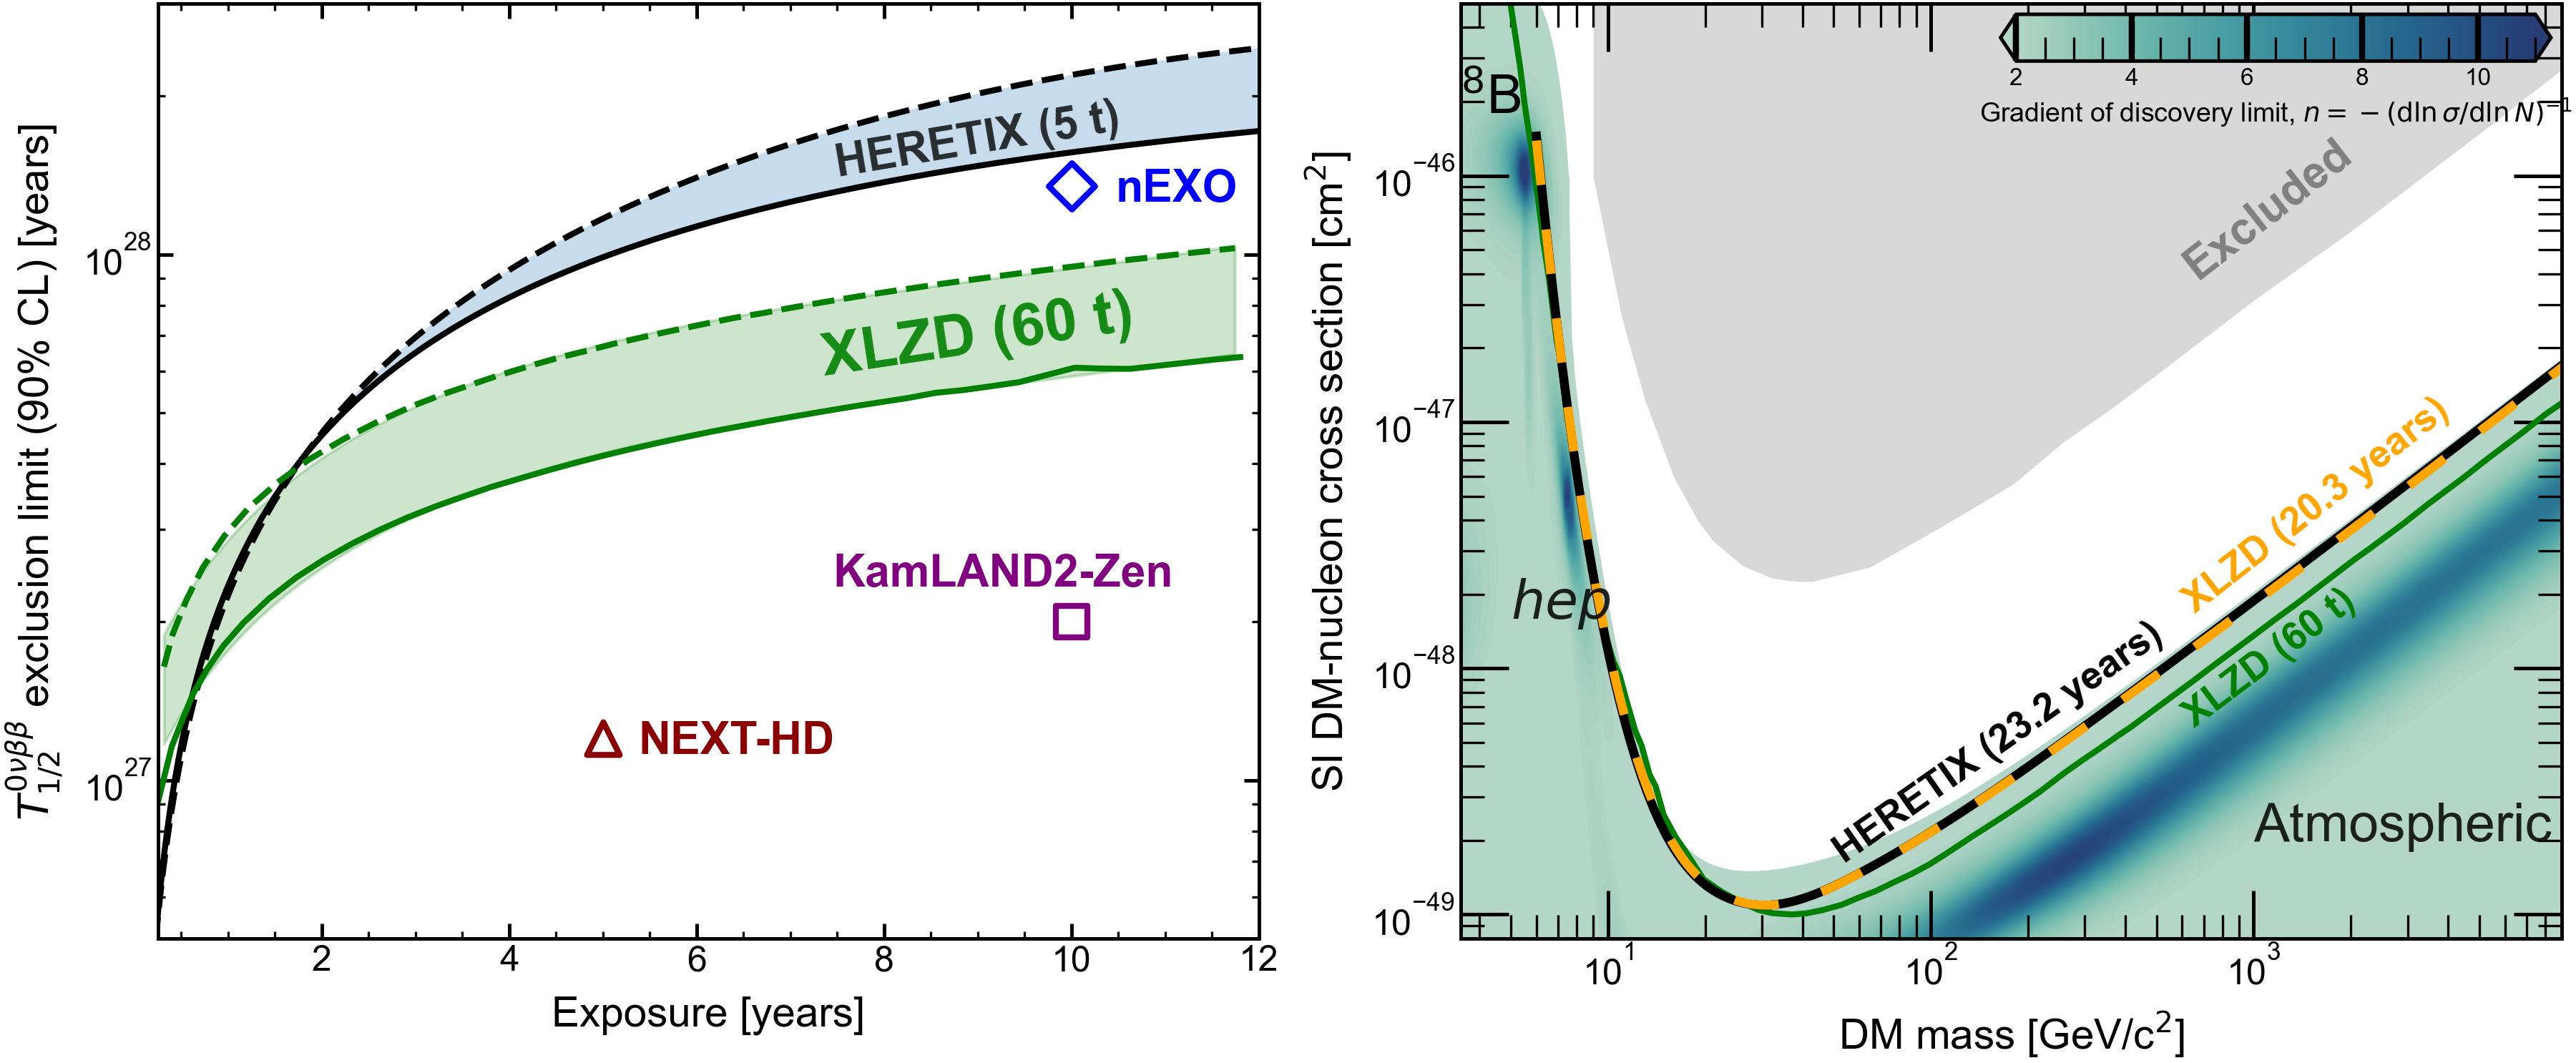

In [193]:
%run twopanel_sensitivities.py

## NR background

In [5]:
import h5py
hdf = h5py.File("data/NR_plot_data.hdf5", "r")
                
#r_co_min = 328.22
#r_co_max = 418.28

r_co_min = 365
r_co_max = 445

r_opt = 1400.0
z_min_opt = -1519.5
z_max_opt = 1203.0

_h_rz_total_values = hdf["NR_rz_total"]["values"][:]
_h_rz_total_edges = [hdf["NR_rz_total"]["axis_0_edges"][:], hdf["NR_rz_total"]["axis_1_edges"][:]]

hdf = h5py.File("data/ER_plot_data.hdf5", "r")
_h_rz_ER_values = hdf["ER_rz_total"]["values"][:]
_h_rz_ER_edges = [hdf["ER_rz_total"]["axis_0_edges"][:], hdf["ER_rz_total"]["axis_1_edges"][:]]

z_min_0vbb = (z_min_opt+z_max_opt)/2-962.5
z_max_0vbb = (z_min_opt+z_max_opt)/2+962.5

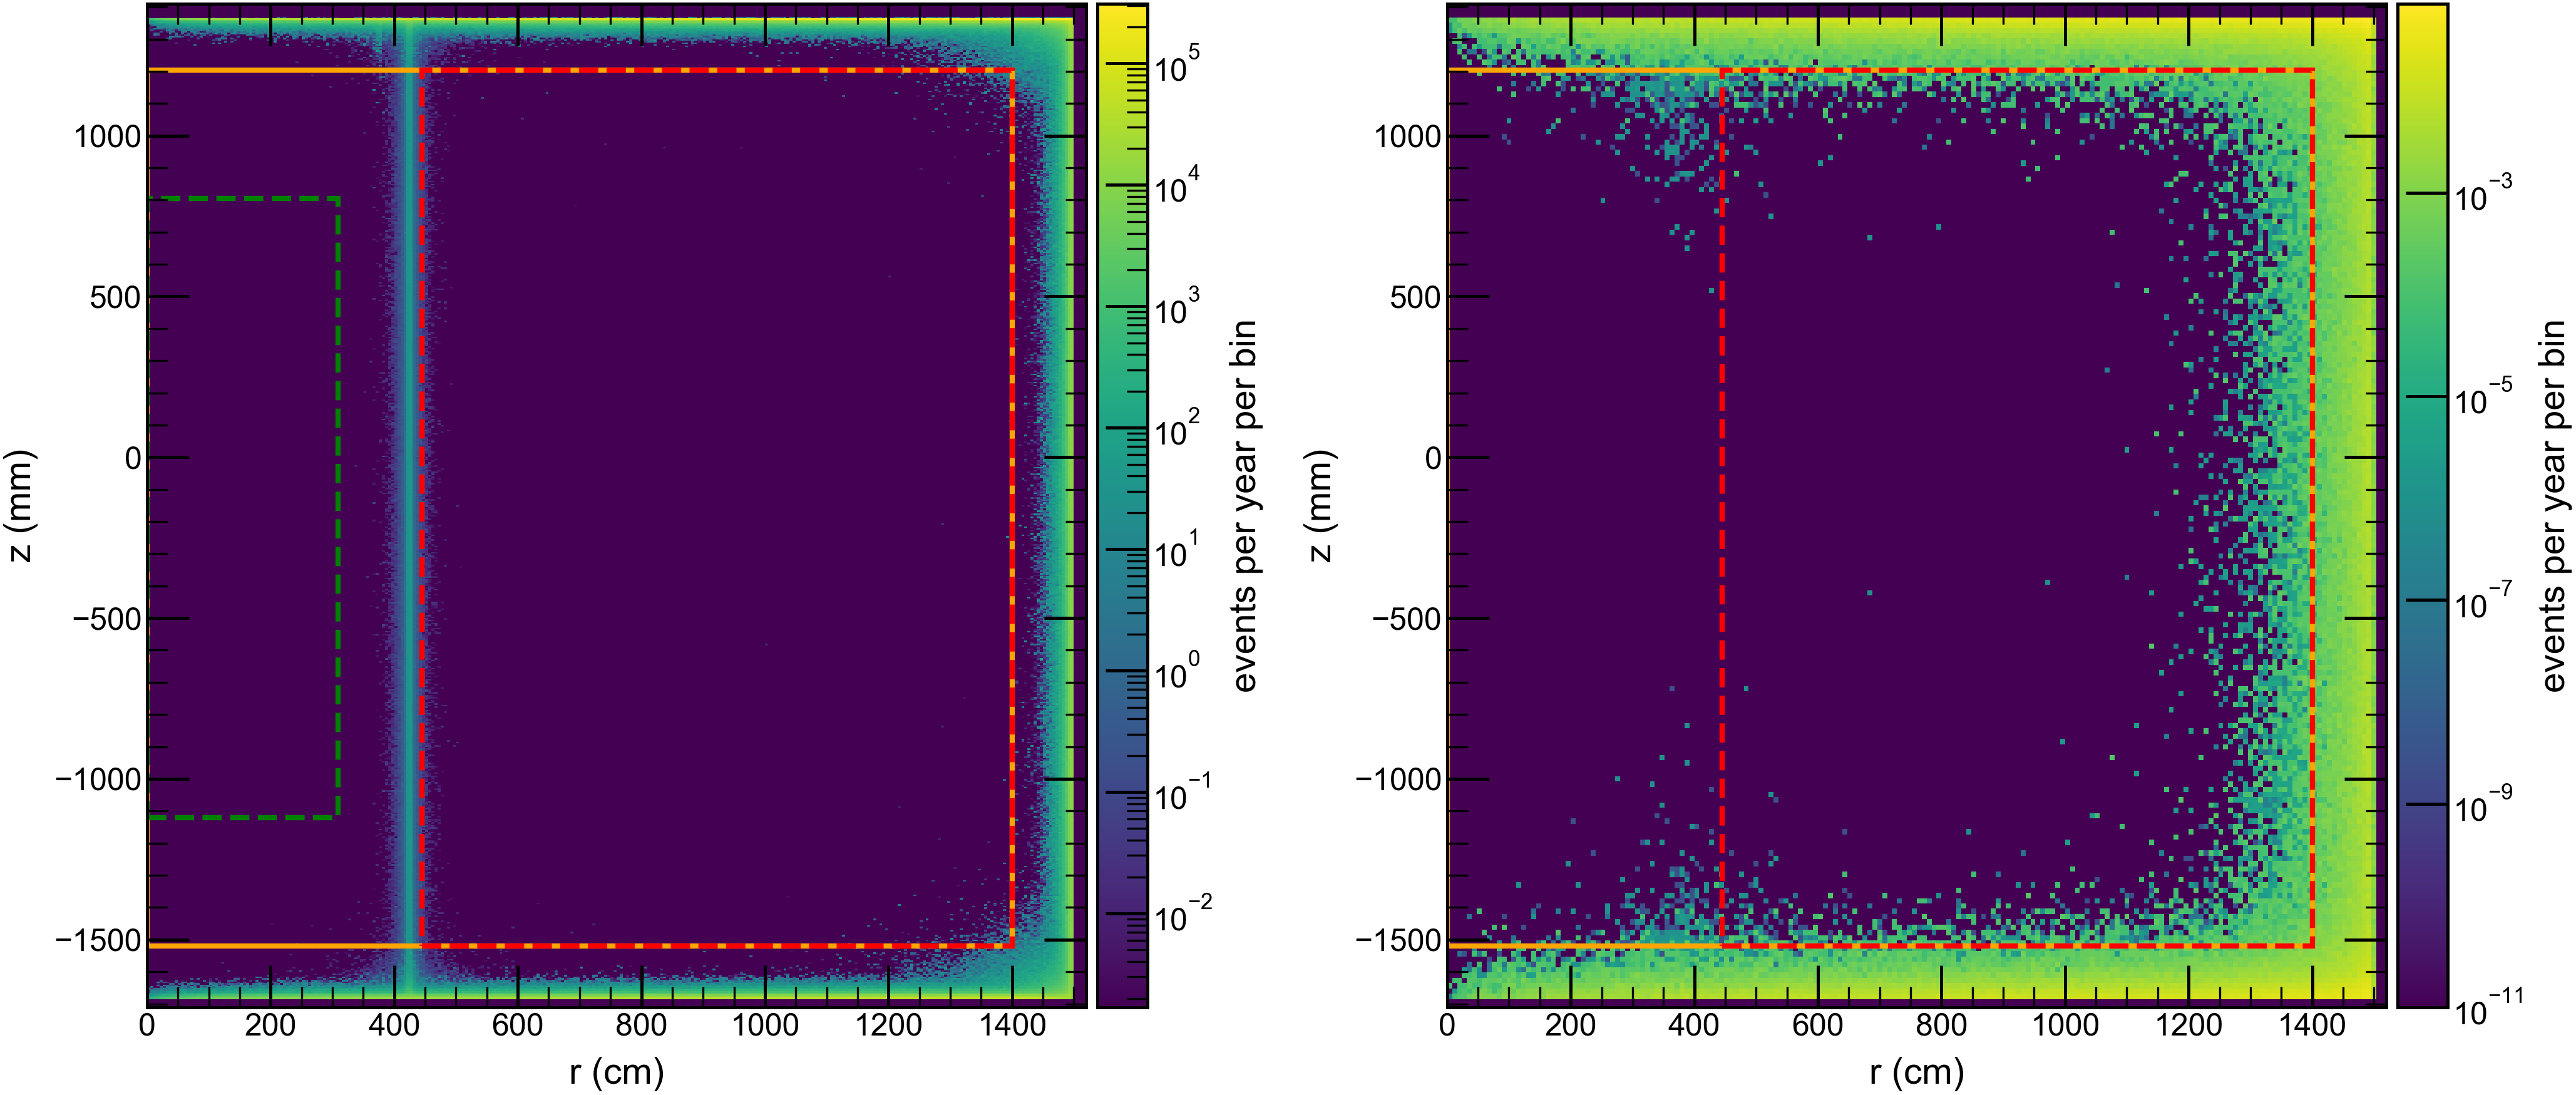

In [ ]:
fig, (ax1, ax3) = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

cmap = mpl.cm.viridis.copy()
low_color = cmap(0.0)
cmap.set_bad(low_color)
cmap.set_under(low_color)

data = _h_rz_ER_values
data_mask = np.ma.masked_equal(data, 0)
norm = mpl.colors.LogNorm(vmin=np.nanmax([data_mask.min(), 1e-11]), vmax=data_mask.max())

pcm1 = ax1.pcolormesh(*_h_rz_ER_edges, _h_rz_ER_values.T, norm=norm, cmap=cmap)
ax1.add_patch(plt.Rectangle((0, z_min_opt), r_opt, z_max_opt-z_min_opt, color='orange', fill=False, linestyle='-', linewidth=2))
ax1.add_patch(plt.Rectangle((r_co_max, z_min_opt), r_opt-r_co_max, z_max_opt-z_min_opt, color='red', fill=False, linestyle='--', linewidth=2))
ax1.add_patch(plt.Rectangle((0, z_min_0vbb), 309, z_max_0vbb-z_min_0vbb, color='green', fill=False, linestyle='--', linewidth=2))
ax1.set_facecolor(low_color)

ax1.set_xlim(0, 1520)
ax1.set_ylim(-1710, 1410)

ax1.set_xlabel("r (cm)")
ax1.set_ylabel("z (mm)")

data = _h_rz_total_values
data_mask = np.ma.masked_equal(data, 0)
norm = mpl.colors.LogNorm(vmin=np.nanmax([data_mask.min(), 1e-11]), vmax=data_mask.max())

pcm3 = ax3.pcolormesh(*_h_rz_total_edges, _h_rz_total_values.T, norm=norm, cmap=cmap)
ax3.add_patch(plt.Rectangle((0, z_min_opt), r_opt, z_max_opt-z_min_opt, color='orange', fill=False, linestyle='-', linewidth=2))
ax3.add_patch(plt.Rectangle((r_co_max, z_min_opt), r_opt-r_co_max, z_max_opt-z_min_opt, color='red', fill=False, linestyle='--', linewidth=2))

ax3.set_xlim(0, 1520)
ax3.set_ylim(-1710, 1410)

ax3.set_xlabel("r [cm]")
ax3.set_ylabel("z [mm]")

plt.colorbar(pcm1, label="events per year per bin", ax=ax1, pad=0.01)
plt.colorbar(pcm3, label="events per year per bin", ax=ax3, pad=0.01)
fig.tight_layout()

plt.show()